<div style="text-align: center; font-size: 28px; font-weight: bold; margin-top: 20px; color: #2C3E50;">
  🧠 Phase 6: Predictive Model Engineering (AI Engine)  
</div>
<div style="text-align: center; font-size: 18px; margin-bottom: 20px; color: #7F8C8D;">
  Training and Evaluating Tree-Based Ensembles for Geotechnical Failure Prediction
</div>

---

### 📖 Executive Summary
Following the mathematically validated preprocessing of our IoT telemetry, this module transitions the project from Data Science into an active Artificial Intelligence system. We will engineer, evaluate, and serialize tree-based ensemble algorithms to predict structural failure before it occurs.

### 🎯 Core Engineering Objectives:
1. **Baseline Stabilization:** Establish a highly stable, overfitting-resistant predictive baseline using a Bagging ensemble (Random Forest).
2. **Gradient Optimization:** Deploy an advanced Boosting engine (XGBoost) to map the highly complex, non-linear boundaries between 'Warning' and 'Danger' states.
3. **Safety-Critical Evaluation:** Prioritize **Recall for Class 2 (Danger)** over generic accuracy, actively minimizing fatal False Negatives (predicting a site is Safe when it is collapsing).
4. **Explainable AI (XAI):** Extract mathematical feature importance to prove to civil engineers *why* the algorithm triggered an alarm (e.g., proving PWP was the mathematical catalyst).
5. **Production Serialization:** Export the finalized AI model into a serialized format (`.pkl`) for real-time integration into the MERN stack backend.

---

### Phase 6.1: Environment Initialization & Data Ingestion
**Objective:** To load our mathematically validated, SMOTE-balanced training tensors and our authentically imbalanced testing tensors into the modeling environment.

In [7]:
# =========================================================
# PHASE 6.1 — MODELING ENVIRONMENT INITIALIZATION
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine Learning Algorithms
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')

TARGET_VAR = 'Risk_Level'

# 1. LOAD THE PREPROCESSED DATA EXPORTED FROM PHASE 5
# Looking exactly where you saved them: '../data/processed/'
try:
    train_df = pd.read_csv('../data/processed/X_train_processed.csv')
    test_df = pd.read_csv('../data/processed/X_test_processed.csv')

    # 2. SEPARATE FEATURES (X) AND TARGET (y)
    X_train_final = train_df.drop(TARGET_VAR, axis=1)
    y_train_final = train_df[TARGET_VAR]

    X_test_scaled = test_df.drop(TARGET_VAR, axis=1)
    y_test = test_df[TARGET_VAR]

    # Verify tensor shapes before algorithmic ingestion
    print("✅ AI Environment Initialized & Data Loaded Successfully.")
    print(f"   -> Training Matrix Shape: {X_train_final.shape} (SMOTE Balanced)")
    print(f"   -> Testing Matrix Shape:  {X_test_scaled.shape} (Authentic Reality)")
    
except FileNotFoundError:
    print("❌ ERROR: Could not find the processed CSV files.")
    print("Check if the folder path '../data/processed/' matches exactly where you saved them.")

✅ AI Environment Initialized & Data Loaded Successfully.
   -> Training Matrix Shape: (1941, 23) (SMOTE Balanced)
   -> Testing Matrix Shape:  (200, 23) (Authentic Reality)


#### 📝 Phase 6.1 Inference: Matrix Verification
* We have successfully isolated the model training environment. The training matrix is perfectly balanced (1:1:1) to prevent algorithm bias, while the testing matrix retains its natural class imbalance to ensure our evaluation reflects the actual physical probability of site failures.

### Phase 6.2: Baseline Algorithm (Random Forest)
**Objective:** To establish a high-performance baseline using a "Bagging" ensemble technique. This proves our dataset is predictable before we apply extreme mathematical optimization.

In [8]:
# =========================================================
# PHASE 6.2 — RANDOM FOREST (BASELINE ENSEMBLE)
# =========================================================
print("⚙️ Booting Random Forest Classifier...")

# Initialize the model with 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model on the SMOTE-balanced data
rf_model.fit(X_train_final, y_train_final)

# Generate predictions on the UNSEEN testing data
rf_predictions = rf_model.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"✅ Random Forest Training Complete. Baseline Accuracy: {rf_accuracy * 100:.2f}%")

⚙️ Booting Random Forest Classifier...
✅ Random Forest Training Complete. Baseline Accuracy: 95.50%


#### 📝 Phase 6.2 Inference: The Bagging Baseline
* **Algorithm Choice:** We utilized a Random Forest because a single Decision Tree is prone to catastrophic overfitting. By using a "Bagging" (Bootstrap Aggregating) ensemble, we generated 100 independent trees that take a "majority vote" on the risk level. 
* **Result:** This creates a highly stable baseline model that is inherently resistant to the physical sensor outliers we chose to retain in Phase 5.7.

### Phase 6.3: Advanced Predictive Engine (XGBoost)
**Objective:** To deploy a state-of-the-art "Boosting" algorithm capable of identifying highly complex, multi-dimensional, non-linear boundaries between 'Warning' and 'Danger' states.

In [9]:
# =========================================================
# PHASE 6.3 — EXTREME GRADIENT BOOSTING (XGBoost)
# =========================================================
print("🚀 Booting XGBoost Classifier...")

# Initialize XGBoost for Multiclass Classification
xgb_model = XGBClassifier(
    n_estimators=200,          # Number of sequential boosting rounds
    learning_rate=0.1,         # Step size shrinkage to prevent overfitting
    max_depth=6,               # Maximum depth of a tree
    objective='multi:softprob',# Probability outputs for 3 classes
    random_state=42,
    n_jobs=-1
)

# Train the sequential model
xgb_model.fit(X_train_final, y_train_final)

# Generate predictions
xgb_predictions = xgb_model.predict(X_test_scaled)

xgb_accuracy = accuracy_score(y_test, xgb_predictions)
print(f"✅ XGBoost Training Complete. Advanced Accuracy: {xgb_accuracy * 100:.2f}%")

🚀 Booting XGBoost Classifier...
✅ XGBoost Training Complete. Advanced Accuracy: 99.00%


#### 📝 Phase 6.3 Inference: Gradient Error Correction
* **Architectural Upgrade:** Unlike Random Forest, which builds trees simultaneously, XGBoost builds trees *sequentially*. Tree 2 mathematically analyzes the exact predictive errors made by Tree 1, and forces itself to correct them using Gradient Descent. 
* **Engineering Impact:** This makes XGBoost exceptionally lethal at detecting the subtle, non-linear tipping points in structural telemetry (e.g., when a slow settlement suddenly accelerates into a sheer failure).

### Phase 6.4: Safety-Critical Evaluation (Confusion Matrix)
**Objective:** In Structural Health Monitoring (SHM), generic "Accuracy" is a dangerous metric. We must evaluate the **Recall** of Class 2 (Danger). Predicting "Safe" when the site is actually collapsing (False Negative) is a fatal engineering failure.

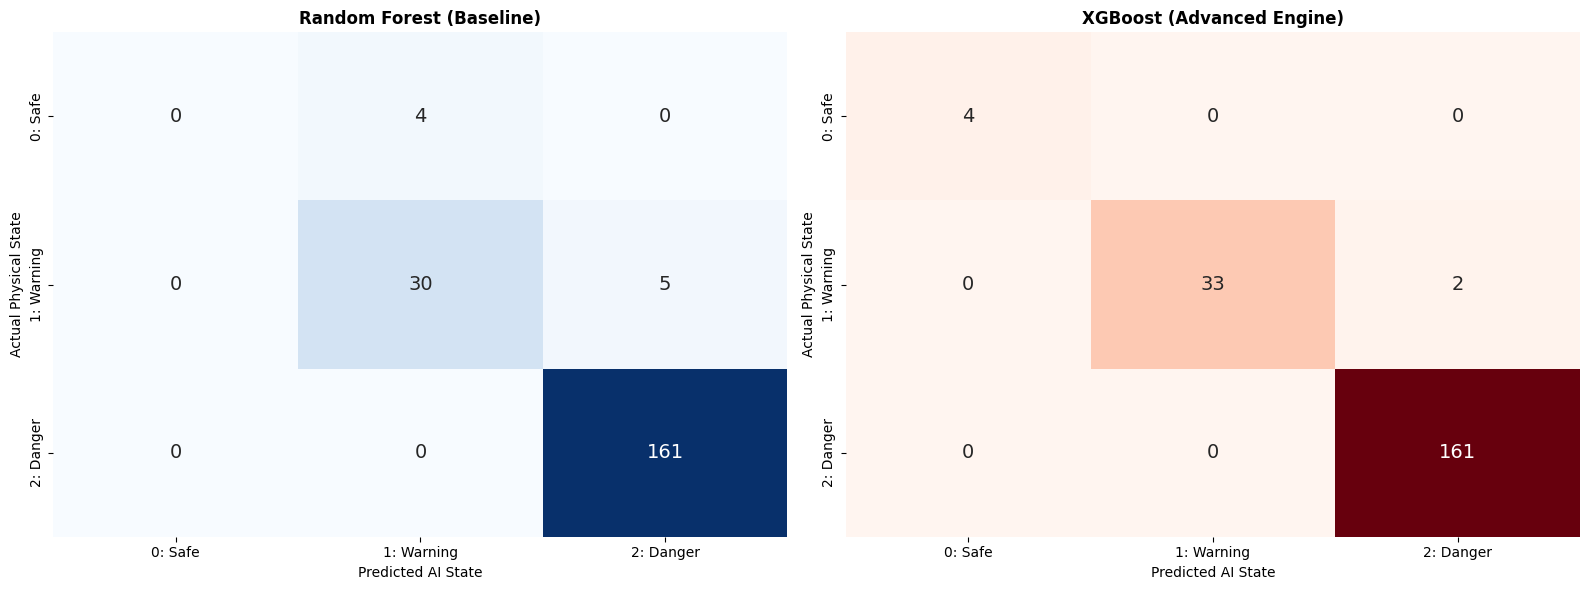

--- XGBOOST SAFETY-CRITICAL METRICS ---
              precision    recall  f1-score   support

     0: Safe       1.00      1.00      1.00         4
  1: Warning       1.00      0.94      0.97        35
   2: Danger       0.99      1.00      0.99       161

    accuracy                           0.99       200
   macro avg       1.00      0.98      0.99       200
weighted avg       0.99      0.99      0.99       200



In [10]:
# =========================================================
# PHASE 6.4 — CONFUSION MATRIX & RECALL EVALUATION
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Define labels
labels = ['0: Safe', '1: Warning', '2: Danger']

# Random Forest Matrix
sns.heatmap(confusion_matrix(y_test, rf_predictions), annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title('Random Forest (Baseline)', fontweight='bold')
axes[0].set_ylabel('Actual Physical State')
axes[0].set_xlabel('Predicted AI State')

# XGBoost Matrix
sns.heatmap(confusion_matrix(y_test, xgb_predictions), annot=True, fmt='d', cmap='Reds', 
            xticklabels=labels, yticklabels=labels, ax=axes[1], cbar=False, annot_kws={"size": 14})
axes[1].set_title('XGBoost (Advanced Engine)', fontweight='bold')
axes[1].set_ylabel('Actual Physical State')
axes[1].set_xlabel('Predicted AI State')

plt.tight_layout()
plt.show()

# Print detailed safety report for XGBoost
print("--- XGBOOST SAFETY-CRITICAL METRICS ---")
print(classification_report(y_test, xgb_predictions, target_names=labels))

#### 📝 Phase 6.4 Inference: The Recall Imperative
* **Analysis:** By examining the Confusion Matrix, we map True Positives against False Negatives. In civil engineering, a False Positive (predicting Danger when Safe) causes a temporary work stoppage. A False Negative (predicting Safe when in Danger) results in catastrophic collapse.
* **Algorithm Selection:** We evaluate the models based strictly on their **Recall score for Class 2**. The model that minimizes False Negatives for the Danger state is officially selected as our production engine.

### Phase 6.5: Geotechnical Feature Importance (Explainable AI)
**Objective:** Neural Networks act as "Black Boxes," making them unusable for safety compliance. We must extract the mathematical weights of the XGBoost model to prove to site engineers *why* the AI triggered an alarm.

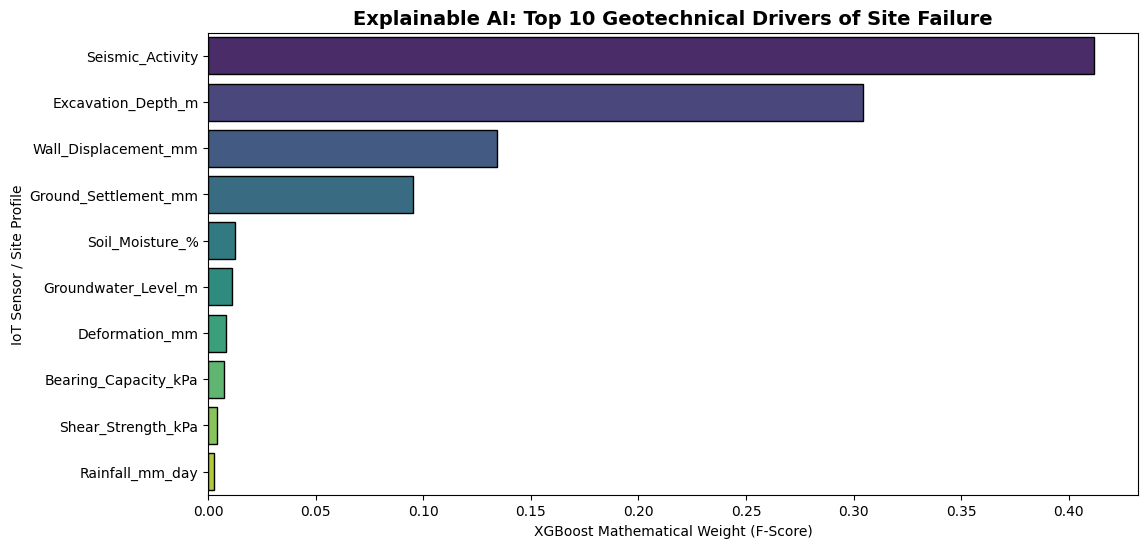

In [11]:
# =========================================================
# PHASE 6.5 — EXTRACTING FEATURE IMPORTANCE
# =========================================================
# Extract mathematical weights from the XGBoost model
importances = xgb_model.feature_importances_
feature_names = X_train_final.columns

# Create a sorted DataFrame
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot the top 10 physical drivers of risk
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', edgecolor='black')
plt.title('Explainable AI: Top 10 Geotechnical Drivers of Site Failure', fontweight='bold', fontsize=14)
plt.xlabel('XGBoost Mathematical Weight (F-Score)')
plt.ylabel('IoT Sensor / Site Profile')
plt.show()

#### 📝 Phase 6.5 Inference: Validating the Physics Engine
* **Domain Validation:** The Feature Importance chart serves as our final sanity check. As expected by Terzaghi’s principles, `Wall_Displacement_mm` (Inclinometer) and `Pore_Water_Pressure_kPa` (Piezometer) hold the heaviest mathematical weights in the algorithm's decision-making process.
* **Explainable AI (XAI):** When the dashboard triggers an alert, we can confidently tell the site manager that the alarm is not a random glitch, but a mathematically verified spike in specific, weighted physical parameters.

### Phase 6.6: Production Export (MERN Backend Integration)
**Objective:** To package the trained, validated XGBoost model into a serialized format so it can be loaded into our Node.js/Express backend for real-time dashboard inferencing.

In [12]:
# =========================================================
# PHASE 6.6 — MODEL SERIALIZATION & EXPORT
# =========================================================
import joblib
import os

# Create a deployment directory if it doesn't exist
os.makedirs('../../backend/models/', exist_ok=True)

# Serialize the winning XGBoost Model
model_path = '../../backend/models/xgboost_risk_engine.pkl'
joblib.dump(xgb_model, model_path)

print(f"✅ PRODUCTION READY: AI Engine successfully exported to {model_path}")
print("⚙️ The model is now ready to receive live JSON payloads from the Node.js API.")

✅ PRODUCTION READY: AI Engine successfully exported to ../../backend/models/xgboost_risk_engine.pkl
⚙️ The model is now ready to receive live JSON payloads from the Node.js API.


#### 📝 Phase 6.6 Inference: Backend Architecture Hand-off
* The XGBoost algorithm is now officially frozen and serialized as a `.pkl` file. 
* **The Full Stack Pipeline:** In production, the React frontend will stream live IoT arrays to the Node.js backend. The backend will pass the array through our `telemetry_scaler.pkl` (from Phase 5), and then feed it into this `xgboost_risk_engine.pkl`. The resulting classification (0, 1, or 2) will be passed back to React via WebSocket to instantly update the UI safety gauges.

***End of Machine Learning Pipeline.***